In [1]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
# Load the dataset
data = pd.read_csv("../../data/Test Data.csv")

In [3]:
data

,Date,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,1-Apr-23,23286.87,5.633309,0.679596,98.804118,0.988493,12.778676,0.317022,34.709118,43047497.21,46889,251417.5882,149.154412,49209296.38,43.460147,6161799.12
1,1-Aug-23,23677.76,7.364028,0.471457,95.325628,0.820870,7.653198,0.066296,35.626903,50313422.69,59988,122458.1053,3983.046559,56692531.22,40.117105,6379108.66
2,1-Dec-22,20755.21,5.066298,0.644504,97.453779,0.917099,10.162252,0.093053,34.349733,38831073.14,41009,244848.5649,2167.549618,44311619.79,35.898473,5480546.64
3,1-Feb-23,21880.87,5.382316,0.792096,98.227500,1.016471,12.823051,0.202574,35.099449,39888353.28,43346,241229.6471,22.955882,45724214.07,42.006801,5835860.74
4,1-Jan-23,20811.78,5.389850,0.704850,98.747444,0.939248,10.303647,0.164361,36.835038,36907578.16,40927,241561.7820,0.000000,42734990.38,37.557368,5827412.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,9-Mar-23,23350.58,5.057684,0.742757,98.266507,1.002463,12.961728,0.197096,35.234963,41676401.56,45812,249644.5074,6.106618,47851202.93,41.218088,6174801.32
362,9-May-23,22459.26,5.047216,0.716923,99.384286,1.012454,9.975018,0.304176,34.966886,42117368.21,45766,249021.0330,447.410256,48156570.69,42.919341,6039202.57
363,9-Nov-22,17475.45,3.133588,0.517557,97.921145,0.927290,11.786832,0.102977,35.045382,29272509.30,39918,218947.5573,1449.561069,33761716.22,38.948511,4489206.83
364,9-Oct-22,16437.81,3.316680,0.559040,98.747840,0.959960,10.710440,0.130640,35.621360,30127950.12,34459,216222.9000,694.732000,34672216.32,37.295080,4544265.80


In [11]:
# Convert 'Date' column to datetime format and set it as the index
data['Date'] = pd.to_datetime(data['Date'], format='%d-%b-%y')
data.set_index('Date', inplace=True)

KeyError: 'Date'

In [18]:
# Group by 'Date' and calculate the average for each column
data_avg = data.groupby('Date').mean()

In [19]:
data_avg

,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
Date,,,,,,,,,,,,,,,
2022-09-01,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848.0,251968.1429,393.651786,32890183.17,37.050402,4142157.11
2022-09-02,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313.0,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2022-09-03,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565.0,246798.6027,388.062500,33383868.74,36.708884,4281017.27
2022-09-04,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303.0,257327.6563,387.245536,32606986.82,36.628527,4140106.66
2022-09-05,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314.0,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-28,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629.0,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
2023-08-29,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688.0,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
2023-08-30,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111.0,133872.1556,362.741936,65854384.38,40.078159,7464569.80


In [20]:
# Sort the data by date to ensure it is in chronological order
data_avg = data_avg.sort_index()

In [21]:
# Focus on the target variables: Downlink and Uplink Throughput
dl_throughput = data_avg['Average User Throughput DL']
ul_throughput = data_avg['Average User Throughput UL']

In [22]:
# Split the data into training and testing sets (e.g., 80% train, 20% test) without shuffling
train_size = int(len(dl_throughput) * 0.8)
train_dl, test_dl = dl_throughput[:train_size], dl_throughput[train_size:]
train_ul, test_ul = ul_throughput[:train_size], ul_throughput[train_size:]

In [23]:
# Train ARIMA model for DL Throughput
arima_dl = ARIMA(train_dl, order=(5, 1, 0))
arima_dl_fit = arima_dl.fit()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [24]:
# Train ARIMA model for UL Throughput
arima_ul = ARIMA(train_ul, order=(5, 1, 0))
arima_ul_fit = arima_ul.fit()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [25]:
# Make predictions
dl_pred = arima_dl_fit.forecast(steps=len(test_dl))
ul_pred = arima_ul_fit.forecast(steps=len(test_ul))

In [26]:
# Evaluate the model
mse_dl = mean_squared_error(test_dl, dl_pred)
mse_ul = mean_squared_error(test_ul, ul_pred)

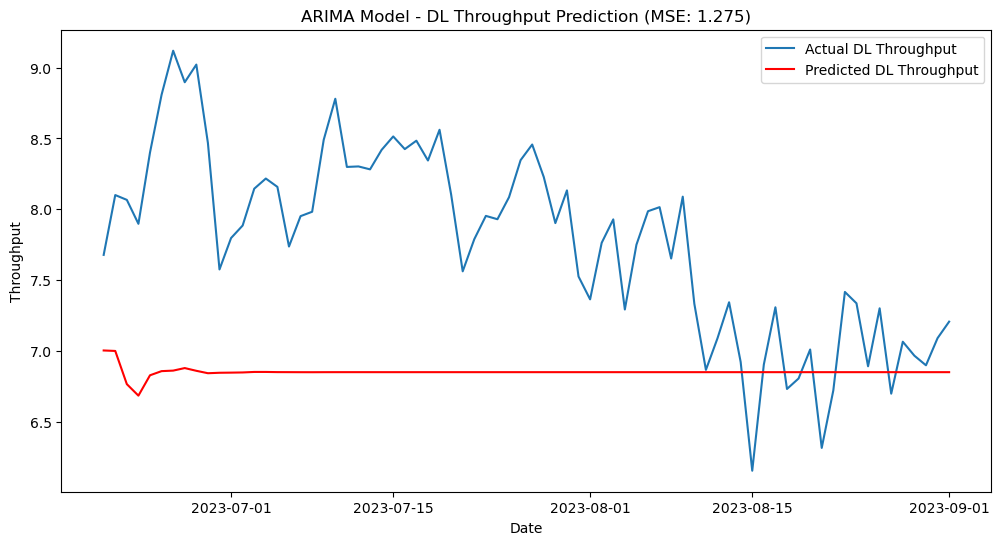

In [27]:
# Plot the results for DL Throughput
plt.figure(figsize=(12, 6))
plt.plot(test_dl.index, test_dl, label='Actual DL Throughput')
plt.plot(test_dl.index, dl_pred, label='Predicted DL Throughput', color='red')
plt.title(f'ARIMA Model - DL Throughput Prediction (MSE: {mse_dl:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()

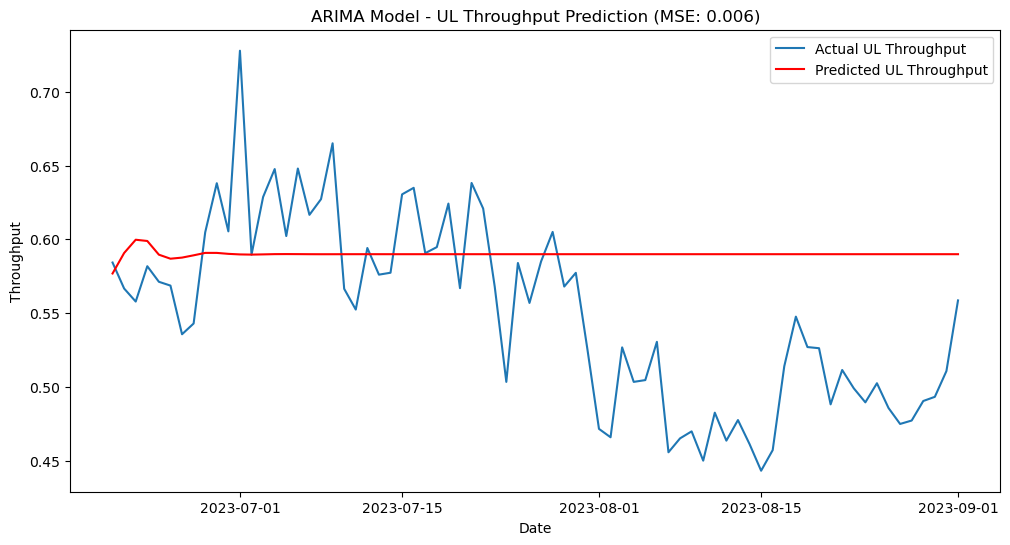

In [28]:
# Plot the results for UL Throughput
plt.figure(figsize=(12, 6))
plt.plot(test_ul.index, test_ul, label='Actual UL Throughput')
plt.plot(test_ul.index, ul_pred, label='Predicted UL Throughput', color='red')
plt.title(f'ARIMA Model - UL Throughput Prediction (MSE: {mse_ul:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()

In [29]:
# Focus on the target variables: User Count Average and Traffic
user_count_avg = data_avg['User Count Average']
traffic = data_avg['Traffic']

# Split the data into training and testing sets (e.g., 80% train, 20% test) without shuffling
train_size = int(len(user_count_avg) * 0.8)
train_user_count, test_user_count = user_count_avg[:train_size], user_count_avg[train_size:]
train_traffic, test_traffic = traffic[:train_size], traffic[train_size:]

# Train ARIMA model for User Count Average
arima_user_count = ARIMA(train_user_count, order=(5, 1, 0))
arima_user_count_fit = arima_user_count.fit()

# Train ARIMA model for Traffic
arima_traffic = ARIMA(train_traffic, order=(5, 1, 0))
arima_traffic_fit = arima_traffic.fit()

# Make predictions
user_count_pred = arima_user_count_fit.forecast(steps=len(test_user_count))
traffic_pred = arima_traffic_fit.forecast(steps=len(test_traffic))

# Evaluate the models
mse_user_count = mean_squared_error(test_user_count, user_count_pred)
mse_traffic = mean_squared_error(test_traffic, traffic_pred)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [33]:
# Normalize the data to the range [1, 10]
user_count_min, user_count_max = user_count_avg.min(), user_count_avg.max()
traffic_min, traffic_max = traffic.min(), traffic.max()

user_count_avg_normalized = 1 + 9 * (user_count_avg - user_count_min) / (user_count_max - user_count_min)
traffic_normalized = 1 + 9 * (traffic - traffic_min) / (traffic_max - traffic_min)

In [36]:

# Split the data into training and testing sets (e.g., 80% train, 20% test) without shuffling
train_size = int(len(user_count_avg_normalized) * 0.8)
train_user_count, test_user_count = user_count_avg_normalized[:train_size], user_count_avg_normalized[train_size:]
train_traffic, test_traffic = traffic_normalized[:train_size], traffic_normalized[train_size:]

# Train ARIMA model for User Count Average
arima_user_count = ARIMA(train_user_count, order=(5, 1, 0))
arima_user_count_fit = arima_user_count.fit()

# Train ARIMA model for Traffic
arima_traffic = ARIMA(train_traffic, order=(5, 1, 0))
arima_traffic_fit = arima_traffic.fit()

# Make predictions
user_count_pred = arima_user_count_fit.forecast(steps=len(test_user_count))
traffic_pred = arima_traffic_fit.forecast(steps=len(test_traffic))

# Evaluate the models
mse_user_count = mean_squared_error(test_user_count, user_count_pred)
mse_traffic = mean_squared_error(test_traffic, traffic_pred)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dat

In [35]:
data_avg

,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
Date,,,,,,,,,,,,,,,
2022-09-01,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848.0,251968.1429,393.651786,32890183.17,37.050402,4142157.11
2022-09-02,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313.0,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2022-09-03,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565.0,246798.6027,388.062500,33383868.74,36.708884,4281017.27
2022-09-04,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303.0,257327.6563,387.245536,32606986.82,36.628527,4140106.66
2022-09-05,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314.0,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-28,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629.0,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
2023-08-29,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688.0,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
2023-08-30,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111.0,133872.1556,362.741936,65854384.38,40.078159,7464569.80


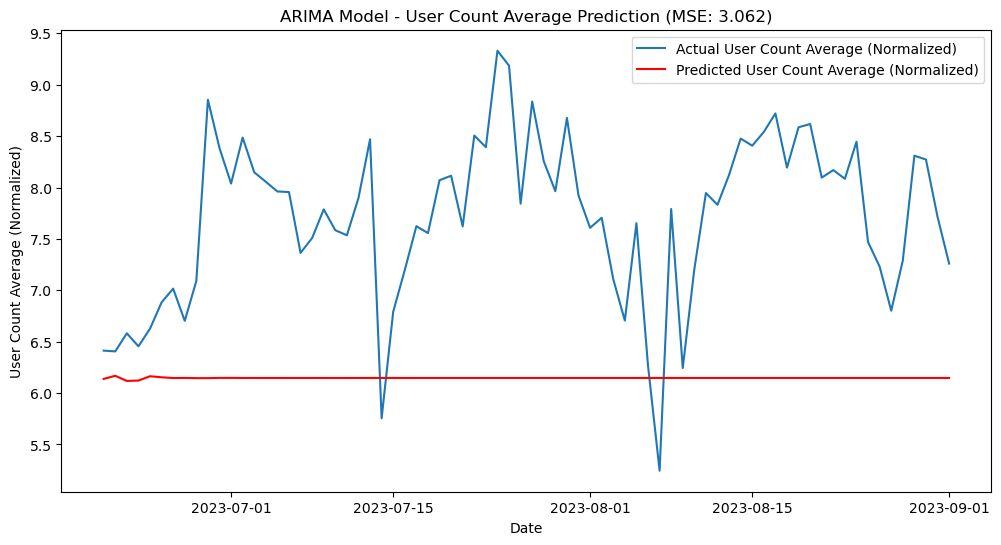

In [37]:
# Plot the results for User Count Average
plt.figure(figsize=(12, 6))
plt.plot(test_user_count.index, test_user_count, label='Actual User Count Average (Normalized)')
plt.plot(test_user_count.index, user_count_pred, label='Predicted User Count Average (Normalized)', color='red')
plt.title(f'ARIMA Model - User Count Average Prediction (MSE: {mse_user_count:.3f})')
plt.xlabel('Date')
plt.ylabel('User Count Average (Normalized)')
plt.legend()
plt.show()

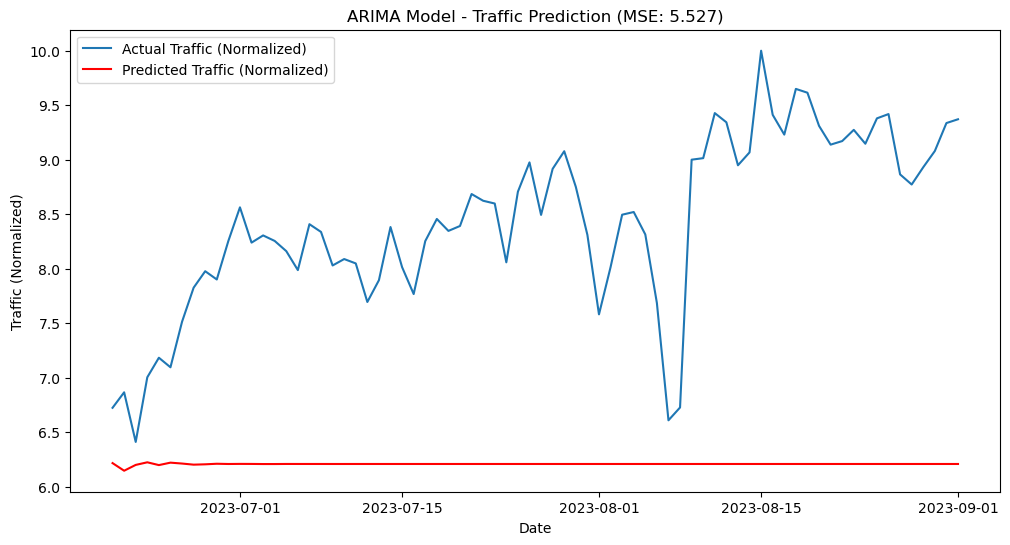

In [38]:
# Plot the results for Traffic
plt.figure(figsize=(12, 6))
plt.plot(test_traffic.index, test_traffic, label='Actual Traffic (Normalized)')
plt.plot(test_traffic.index, traffic_pred, label='Predicted Traffic (Normalized)', color='red')
plt.title(f'ARIMA Model - Traffic Prediction (MSE: {mse_traffic:.3f})')
plt.xlabel('Date')
plt.ylabel('Traffic (Normalized)')
plt.legend()
plt.show()

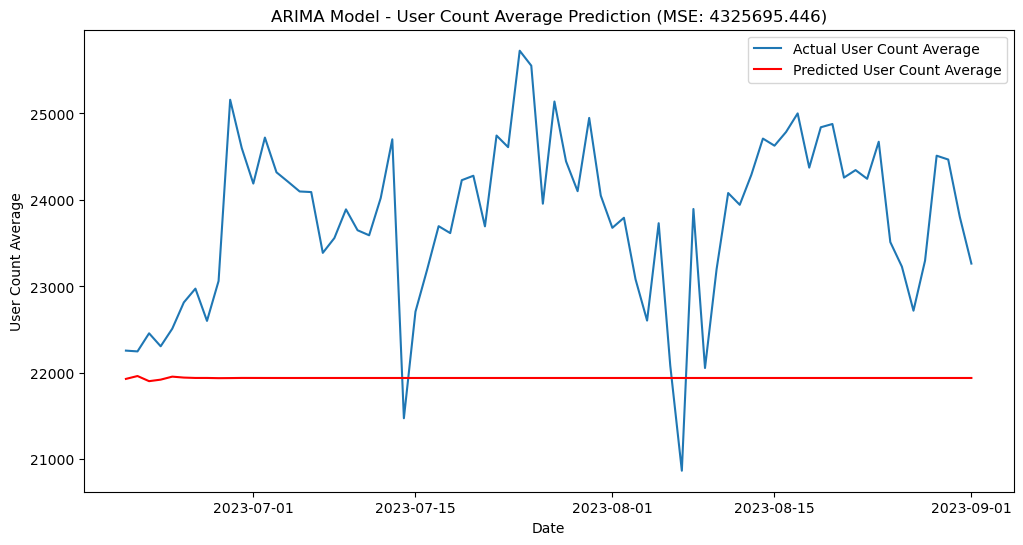

In [30]:
# Plot the results for User Count Average
plt.figure(figsize=(12, 6))
plt.plot(test_user_count.index, test_user_count, label='Actual User Count Average')
plt.plot(test_user_count.index, user_count_pred, label='Predicted User Count Average', color='red')
plt.title(f'ARIMA Model - User Count Average Prediction (MSE: {mse_user_count:.3f})')
plt.xlabel('Date')
plt.ylabel('User Count Average')
plt.legend()
plt.show()

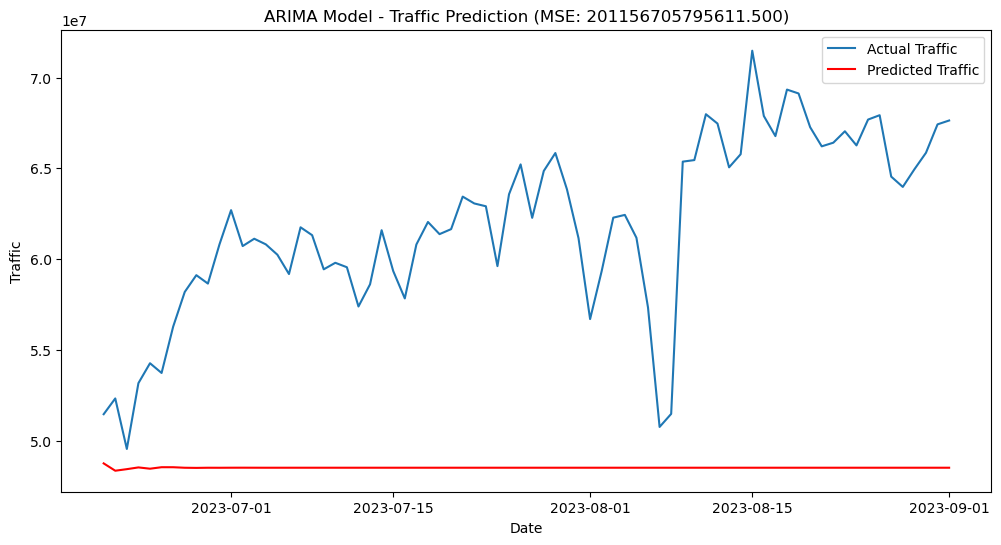

In [31]:
# Plot the results for Traffic
plt.figure(figsize=(12, 6))
plt.plot(test_traffic.index, test_traffic, label='Actual Traffic')
plt.plot(test_traffic.index, traffic_pred, label='Predicted Traffic', color='red')
plt.title(f'ARIMA Model - Traffic Prediction (MSE: {mse_traffic:.3f})')
plt.xlabel('Date')
plt.ylabel('Traffic')
plt.legend()
plt.show()

In [40]:
data_avg

,User Count Average,Average User Throughput DL,Average User Throughput UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,Data Volume DL,User Count Maximum,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
Date,,,,,,,,,,,,,,,
2022-09-01,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848.0,251968.1429,393.651786,32890183.17,37.050402,4142157.11
2022-09-02,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313.0,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2022-09-03,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565.0,246798.6027,388.062500,33383868.74,36.708884,4281017.27
2022-09-04,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303.0,257327.6563,387.245536,32606986.82,36.628527,4140106.66
2022-09-05,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314.0,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-28,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629.0,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
2023-08-29,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688.0,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
2023-08-30,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111.0,133872.1556,362.741936,65854384.38,40.078159,7464569.80


In [41]:
# Select the columns for modeling
variables = data_avg[['User Count Average', 'Traffic', 'Average User Throughput DL']]

# Normalize the data to the range [1, 10]
data_normalized = 1 + 9 * (variables - variables.min()) / (variables.max() - variables.min())


In [42]:
# Split the data into training and testing sets (e.g., 80% train, 20% test) without shuffling
train_size = int(len(data_normalized) * 0.8)
train, test = data_normalized[:train_size], data_normalized[train_size:]


In [44]:
from statsmodels.tsa.vector_ar.var_model import VAR

In [45]:
# Fit a VAR model to the training data
model = VAR(train)
lag_order = model.select_order(maxlags=15)  # Select optimal lag order using criteria like AIC, BIC
model_fitted = model.fit(lag_order.aic)

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [46]:
# Make predictions
forecast = model_fitted.forecast(train.values[-lag_order.aic:], steps=len(test))

In [47]:
# Convert the forecast to a DataFrame and reverse normalization
forecast_df = pd.DataFrame(forecast, index=test.index, columns=train.columns)
forecast_df['Average User Throughput DL'] = forecast_df['Average User Throughput DL'] * (variables['Average User Throughput DL'].max() - variables['Average User Throughput DL'].min()) / 9 + variables['Average User Throughput DL'].min()


In [48]:
# Evaluate the model
mse_dl = mean_squared_error(test['Average User Throughput DL'], forecast_df['Average User Throughput DL'])


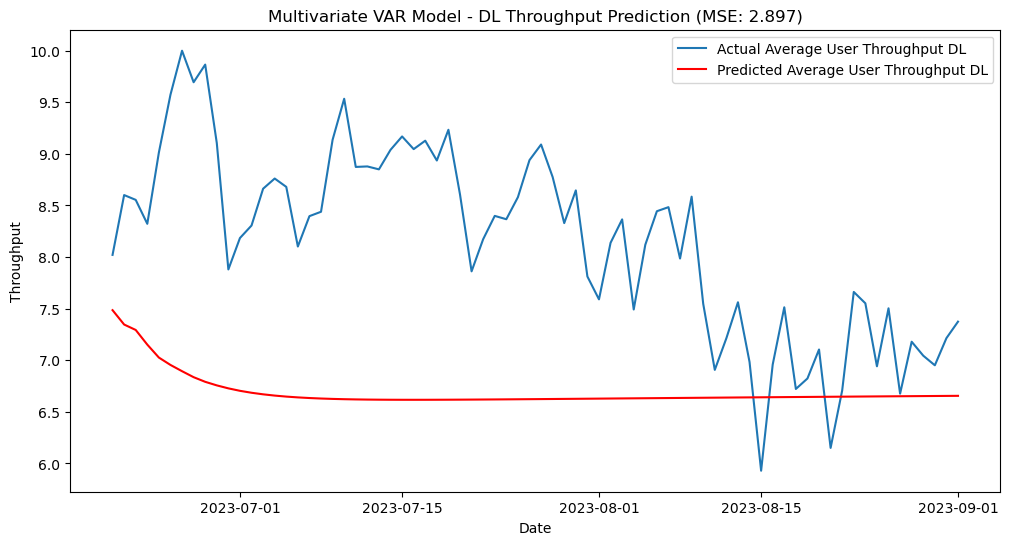

In [49]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Average User Throughput DL'], label='Actual Average User Throughput DL')
plt.plot(test.index, forecast_df['Average User Throughput DL'], label='Predicted Average User Throughput DL', color='red')
plt.title(f'Multivariate VAR Model - DL Throughput Prediction (MSE: {mse_dl:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


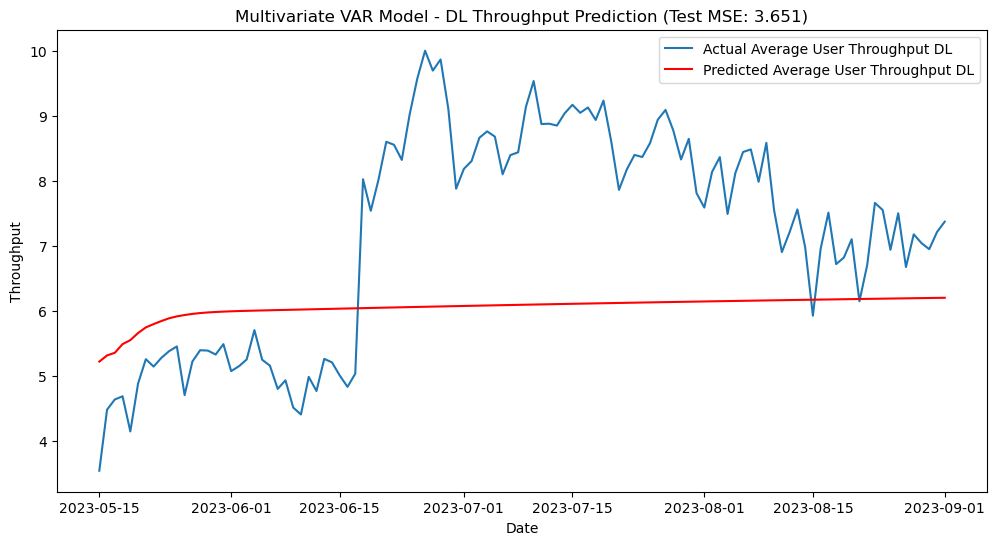

MSE on Training Data: 0.143
MSE on Testing Data: 3.651


In [130]:

# Select the columns for modeling
variables = data_avg[['User Count Average', 'Traffic', 'Average User Throughput DL']]

# Normalize the data to the range [1, 10]
data_normalized = 1 + 9 * (variables - variables.min()) / (variables.max() - variables.min())

# Split the data into training and testing sets (e.g., 80% train, 20% test) without shuffling
train_size = int(len(data_normalized) * 0.7)

train, test = data_normalized[:train_size], data_normalized[train_size:]

# Fit a VAR model to the training data
model = VAR(train)
lag_order = model.select_order(maxlags=15)  # Select optimal lag order using criteria like AIC, BIC
model_fitted = model.fit(lag_order.aic)

# Make predictions
forecast = model_fitted.forecast(train.values[-lag_order.aic:], steps=len(test))

# Convert the forecast to a DataFrame and reverse normalization
forecast_df = pd.DataFrame(forecast, index=test.index, columns=train.columns)
forecast_df['Average User Throughput DL'] = forecast_df['Average User Throughput DL'] * (variables['Average User Throughput DL'].max() - variables['Average User Throughput DL'].min()) / 9 + variables['Average User Throughput DL'].min()

# Truncate the training data to match the length of the fitted values
train_fitted = model_fitted.fittedvalues
train_truncated = train.iloc[lag_order.aic:]

# Evaluate the model
mse_dl_train = mean_squared_error(train_truncated['Average User Throughput DL'], train_fitted['Average User Throughput DL'])
mse_dl_test = mean_squared_error(test['Average User Throughput DL'], forecast_df['Average User Throughput DL'])

# Plot the results for testing data
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Average User Throughput DL'], label='Actual Average User Throughput DL')
plt.plot(test.index, forecast_df['Average User Throughput DL'], label='Predicted Average User Throughput DL', color='red')
plt.title(f'Multivariate VAR Model - DL Throughput Prediction (Test MSE: {mse_dl_test:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()

# Print MSE for both training and testing
print(f'MSE on Training Data: {mse_dl_train:.3f}')
print(f'MSE on Testing Data: {mse_dl_test:.3f}')

C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


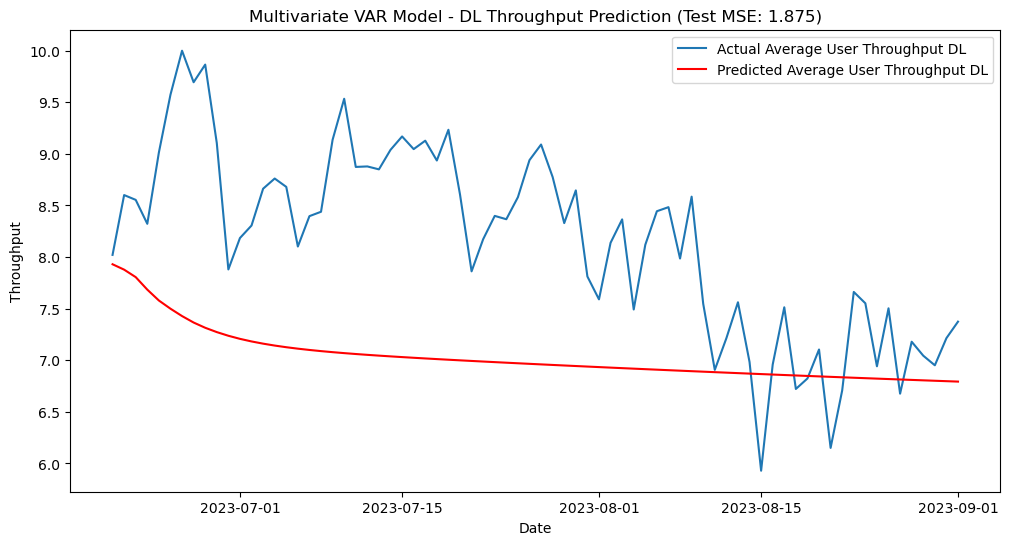

MSE on Training Data: 0.145
MSE on Validation Data: 0.953
MSE on Testing Data: 1.875


<Figure size 640x480 with 0 Axes>

In [120]:

# Split the data into training, validation, and testing sets (e.g., 60% train, 20% validation, 20% test)
train_size = int(len(data_normalized) * 0.7)
valid_size = int(len(data_normalized) * 0.1)
train, validation, test = data_normalized[:train_size], data_normalized[train_size:train_size+valid_size], data_normalized[train_size+valid_size:]

# Fit a VAR model to the training data
model = VAR(train)
lag_order = model.select_order(maxlags=5)  # Select optimal lag order using criteria like AIC, BIC
model_fitted = model.fit(lag_order.aic)

# Make predictions on the training data
train_fitted = model_fitted.fittedvalues
train_truncated = train.iloc[lag_order.aic:]

# Make predictions on the validation set
validation_forecast = model_fitted.forecast(train.values[-lag_order.aic:], steps=len(validation))
validation_forecast_df = pd.DataFrame(validation_forecast, index=validation.index, columns=train.columns)

# Make predictions on the testing set
test_forecast = model_fitted.forecast(data_normalized.values[-lag_order.aic:], steps=len(test))
test_forecast_df = pd.DataFrame(test_forecast, index=test.index, columns=train.columns)

# Reverse normalization for throughput prediction
validation_forecast_df['Average User Throughput DL'] = validation_forecast_df['Average User Throughput DL'] * (variables['Average User Throughput DL'].max() - variables['Average User Throughput DL'].min()) / 9 + variables['Average User Throughput DL'].min()
test_forecast_df['Average User Throughput DL'] = test_forecast_df['Average User Throughput DL'] * (variables['Average User Throughput DL'].max() - variables['Average User Throughput DL'].min()) / 9 + variables['Average User Throughput DL'].min()

# Calculate MSE for training, validation, and testing data
mse_train_dl = mean_squared_error(train_truncated['Average User Throughput DL'], train_fitted['Average User Throughput DL'])
mse_validation_dl = mean_squared_error(validation['Average User Throughput DL'], validation_forecast_df['Average User Throughput DL'])
mse_test_dl = mean_squared_error(test['Average User Throughput DL'], test_forecast_df['Average User Throughput DL'])

# Plot the results for testing data
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Average User Throughput DL'], label='Actual Average User Throughput DL')
plt.plot(test.index, test_forecast_df['Average User Throughput DL'], label='Predicted Average User Throughput DL', color='red')
plt.title(f'Multivariate VAR Model - DL Throughput Prediction (Test MSE: {mse_test_dl:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()

# Save the results for testing data
plt.savefig("Actual Vs Predict_TP_Arima.png")  # Customize filename

# Print MSE for training, validation, and testing
print(f'MSE on Training Data: {mse_train_dl:.3f}')
print(f'MSE on Validation Data: {mse_validation_dl:.3f}')
print(f'MSE on Testing Data: {mse_test_dl:.3f}')

In [54]:
# Decrease the lag order by selecting a smaller value manually
# Let's say we reduce the lag order to 5 (you can adjust based on your data)
lag_order_reduced = 5
model_reduced_lag = VAR(train)
model_fitted_reduced_lag = model_reduced_lag.fit(lag_order_reduced)

# Make predictions on the training, validation, and testing sets
train_fitted_reduced_lag = model_fitted_reduced_lag.fittedvalues
validation_forecast_reduced_lag = model_fitted_reduced_lag.forecast(train.values[-lag_order_reduced:], steps=len(validation))
test_forecast_reduced_lag = model_fitted_reduced_lag.forecast(data_normalized.values[-lag_order_reduced:], steps=len(test))

# Calculate MSE for validation and testing data with reduced lag
mse_validation_reduced_lag = mean_squared_error(validation['Average User Throughput DL'], validation_forecast_reduced_lag[:, 2])
mse_test_reduced_lag = mean_squared_error(test['Average User Throughput DL'], test_forecast_reduced_lag[:, 2])

print(f'MSE on Validation Data (Reduced Lag Order): {mse_validation_reduced_lag:.3f}')
print(f'MSE on Testing Data (Reduced Lag Order): {mse_test_reduced_lag:.3f}')

MSE on Validation Data (Reduced Lag Order): 0.901
MSE on Testing Data (Reduced Lag Order): 2.724


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [55]:
# Print MSE for training, validation, and testing
print(f'MSE on Training Data: {mse_train_dl:.3f}')
print(f'MSE on Validation Data: {mse_validation_dl:.3f}')
print(f'MSE on Testing Data: {mse_test_dl:.3f}')

MSE on Training Data: 0.115
MSE on Validation Data: 3.270
MSE on Testing Data: 1.300


In [56]:
# Assuming the initial training set was 60% of the data, increase to 80%
train_size_extended = int(len(data_normalized) * 0.8)
train_extended, validation_extended, test_extended = data_normalized[:train_size_extended], data_normalized[train_size_extended:train_size_extended+valid_size], data_normalized[train_size_extended+valid_size:]

# Fit the VAR model to the extended training data
model_extended_train = VAR(train_extended)
model_fitted_extended_train = model_extended_train.fit(lag_order.aic)

# Make predictions on the validation and testing sets with extended training data
validation_forecast_extended_train = model_fitted_extended_train.forecast(train_extended.values[-lag_order.aic:], steps=len(validation_extended))
test_forecast_extended_train = model_fitted_extended_train.forecast(data_normalized.values[-lag_order.aic:], steps=len(test_extended))

# Calculate MSE for validation and testing data with extended training data
mse_validation_extended_train = mean_squared_error(validation_extended['Average User Throughput DL'], validation_forecast_extended_train[:, 2])
mse_test_extended_train = mean_squared_error(test_extended['Average User Throughput DL'], test_forecast_extended_train[:, 2])

print(f'MSE on Validation Data (Extended Training Data): {mse_validation_extended_train:.3f}')
print(f'MSE on Testing Data (Extended Training Data): {mse_test_extended_train:.3f}')

MSE on Validation Data (Extended Training Data): 7.562
MSE on Testing Data (Extended Training Data): 0.002


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [122]:

# Assuming the initial training set was 60% of the data, increase to 80%
train_size_combined = int(len(data_normalized) * 0.6)
train_combined, validation_combined, test_combined = data_normalized[:train_size_combined], data_normalized[train_size_combined:train_size_combined+valid_size], data_normalized[train_size_combined+valid_size:]

# Decrease the lag order (let's say to 5)
lag_order_combined = 15

model_combined = VAR(train_combined)
model_fitted_combined = model_combined.fit(lag_order_combined)

# Make predictions on the validation and testing sets
validation_forecast_combined = model_fitted_combined.forecast(train_combined.values[-lag_order_combined:], steps=len(validation_combined))
test_forecast_combined = model_fitted_combined.forecast(data_normalized.values[-lag_order_combined:], steps=len(test_combined))

# Calculate MSE for validation and testing data with combined approach
mse_validation_combined = mean_squared_error(validation_combined['Average User Throughput DL'], validation_forecast_combined[:, 2])
mse_test_combined = mean_squared_error(test_combined['Average User Throughput DL'], test_forecast_combined[:, 2])

print(f'MSE on Validation Data (Combined Approach): {mse_validation_combined:.3f}')
print(f'MSE on Testing Data (Combined Approach): {mse_test_combined:.3f}')

MSE on Validation Data (Combined Approach): 0.844
MSE on Testing Data (Combined Approach): 5.341


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


C:\Users\HP\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


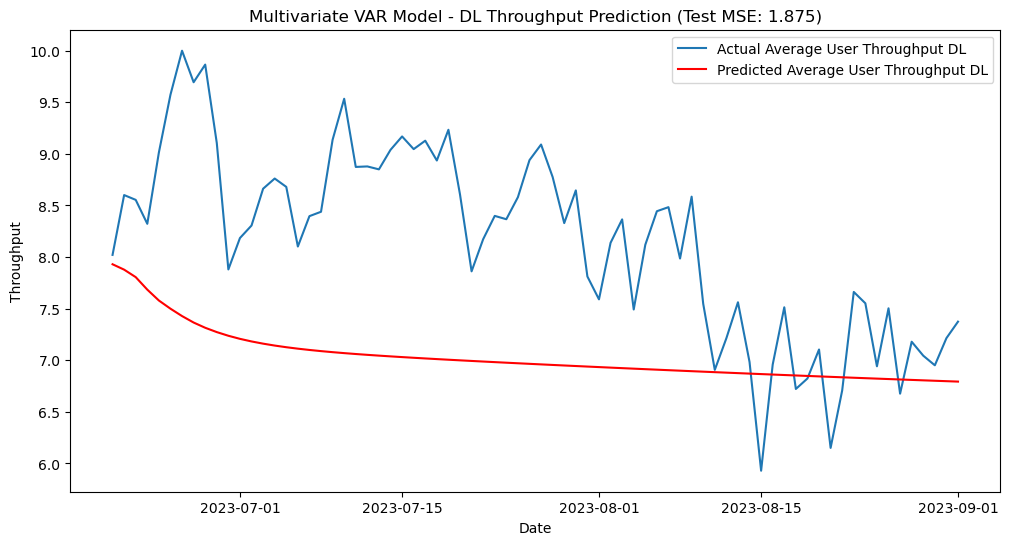

MSE on Training Data: 0.145
MSE on Validation Data: 0.953
MSE on Testing Data: 1.875


<Figure size 640x480 with 0 Axes>

In [132]:

# Split the data into training, validation, and testing sets (e.g., 60% train, 20% validation, 20% test)
train_size = int(len(data_normalized) * 0.7)
valid_size = int(len(data_normalized) * 0.1)
train, validation, test = data_normalized[:train_size], data_normalized[train_size:train_size+valid_size], data_normalized[train_size+valid_size:]

# Fit a VAR model to the training data
model = VAR(train)
lag_order = model.select_order(maxlags=5)  # Select optimal lag order using criteria like AIC, BIC
model_fitted = model.fit(lag_order.aic)

# Make predictions on the training data
train_fitted = model_fitted.fittedvalues
train_truncated = train.iloc[lag_order.aic:]

# Make predictions on the validation set
validation_forecast = model_fitted.forecast(train.values[-lag_order.aic:], steps=len(validation))
validation_forecast_df = pd.DataFrame(validation_forecast, index=validation.index, columns=train.columns)

# Make predictions on the testing set
test_forecast = model_fitted.forecast(data_normalized.values[-lag_order.aic:], steps=len(test))
test_forecast_df = pd.DataFrame(test_forecast, index=test.index, columns=train.columns)

# Reverse normalization for throughput prediction
validation_forecast_df['Average User Throughput DL'] = validation_forecast_df['Average User Throughput DL'] * (variables['Average User Throughput DL'].max() - variables['Average User Throughput DL'].min()) / 9 + variables['Average User Throughput DL'].min()
test_forecast_df['Average User Throughput DL'] = test_forecast_df['Average User Throughput DL'] * (variables['Average User Throughput DL'].max() - variables['Average User Throughput DL'].min()) / 9 + variables['Average User Throughput DL'].min()

# Calculate MSE for training, validation, and testing data
mse_train_dl = mean_squared_error(train_truncated['Average User Throughput DL'], train_fitted['Average User Throughput DL'])
mse_validation_dl = mean_squared_error(validation['Average User Throughput DL'], validation_forecast_df['Average User Throughput DL'])
mse_test_dl = mean_squared_error(test['Average User Throughput DL'], test_forecast_df['Average User Throughput DL'])

# Plot the results for testing data
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['Average User Throughput DL'], label='Actual Average User Throughput DL')
plt.plot(test.index, test_forecast_df['Average User Throughput DL'], label='Predicted Average User Throughput DL', color='red')
plt.title(f'Multivariate VAR Model - DL Throughput Prediction (Test MSE: {mse_test_dl:.3f})')
plt.xlabel('Date')
plt.ylabel('Throughput')
plt.legend()
plt.show()

# Save the results for testing data as per VAR
plt.savefig("Actual Vs Predict_TP_VAR.png")  # Customize filename

# Print MSE for training, validation, and testing
print(f'MSE on Training Data: {mse_train_dl:.3f}')
print(f'MSE on Validation Data: {mse_validation_dl:.3f}')
print(f'MSE on Testing Data: {mse_test_dl:.3f}')